# Phase 1 (Data Exploration)

In [1]:
# Import Required Libraries


import os
import random
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

warnings.filterwarnings("ignore")

# Plot style
plt.style.use("ggplot")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:

# Dataset Path


DATASET_PATH = r"C:\Users\khage\Garbage-Classification\dataset"

if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(f"Dataset not found at: {DATASET_PATH}")

classes = sorted(os.listdir(DATASET_PATH))

print("=" * 60)
print("Garbage Categories")
print("=" * 60)

for cls in classes:
    print(f"✔ {cls}")

Garbage Categories
✔ cardboard
✔ glass
✔ metal
✔ paper
✔ plastic
✔ trash


In [5]:
# Dataset Summery

dataset_summary = []

for cls in classes:

    class_path = os.path.join(DATASET_PATH, cls)

    image_count = len(os.listdir(class_path))

    dataset_summary.append({
        "Class": cls,
        "Number of Images": image_count
    })

df = pd.DataFrame(dataset_summary)

df

,Class,Number of Images
0,cardboard,403
1,glass,501
2,metal,410
3,paper,594
4,plastic,482
5,trash,137


In [9]:
# Display Dataset Statistics

print("DATASET STATISTICS")
print("="*20)

print(f'Total Classes:{len(df)}' )
print(f"Total Image: {df['Number of Images'].sum()} ")


DATASET STATISTICS
Total Classes:6
Total Image: 2527 


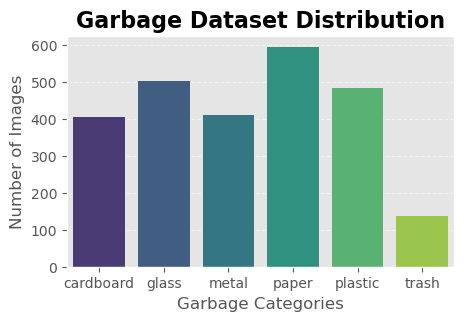

In [15]:
# Visualize Class  Distribution

plt.figure(figsize=(5,3))

sns.barplot(
    data=df,
    x="Class",
    y="Number of Images",
    palette="viridis"
)

plt.title("Garbage Dataset Distribution",fontsize=16,fontweight="bold")
plt.xlabel("Garbage Categories",fontsize=12)
plt.ylabel("Number of Images",fontsize=12)

plt.grid(axis="y",linestyle="--", alpha=0.5)
plt.show()

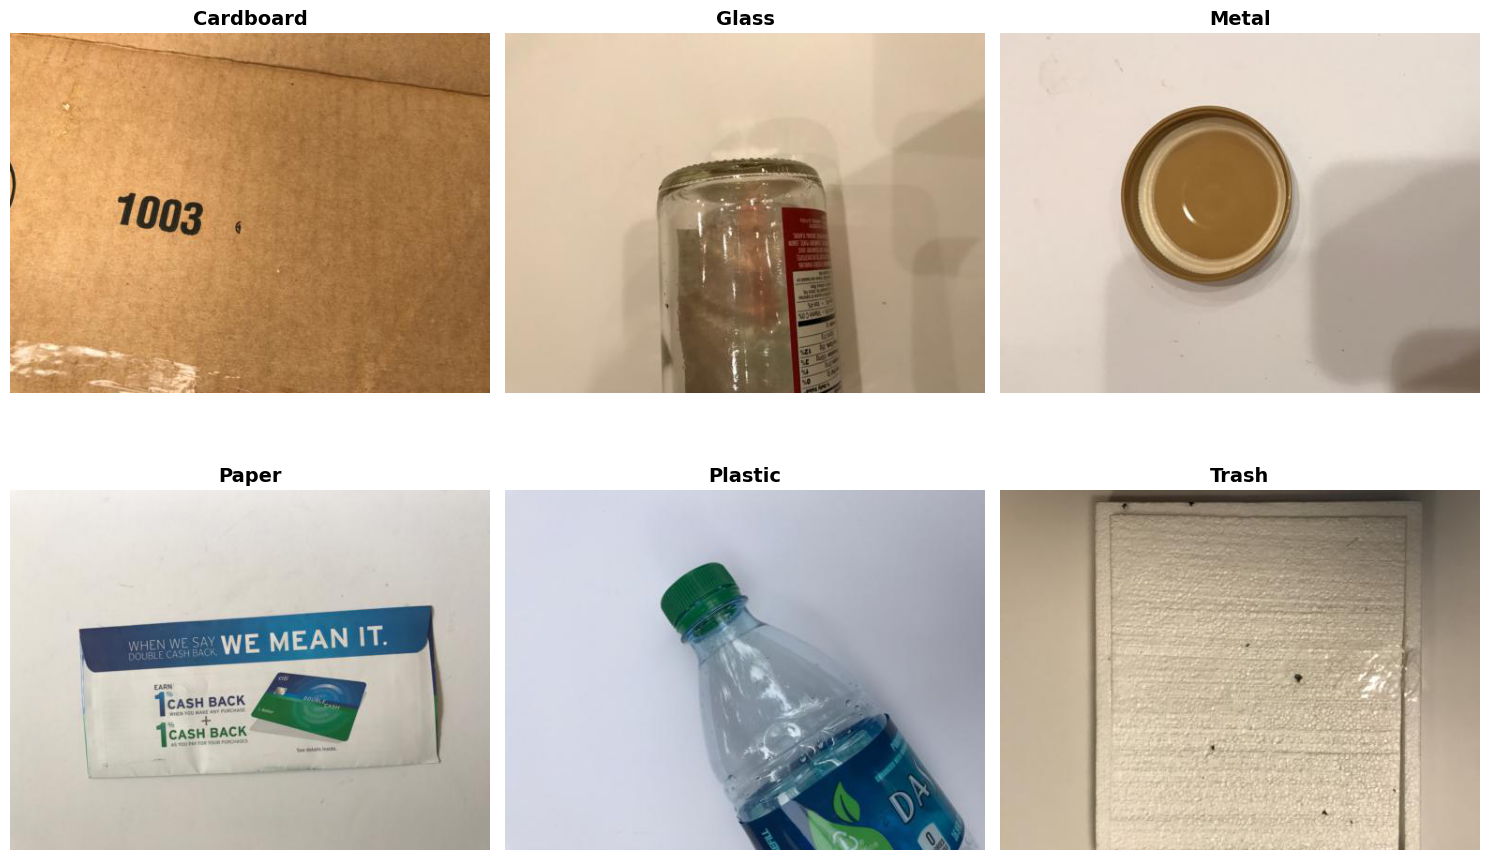

In [17]:
# Display Sample Images

fig, axes = plt.subplots(2, 3, figsize=(15,10))

axes = axes.flatten()

for idx, cls in enumerate(classes):

    class_path = os.path.join(DATASET_PATH, cls)

    image_name = random.choice(os.listdir(class_path))

    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path)

    axes[idx].imshow(image)

    axes[idx].set_title(cls.capitalize(), fontsize=14, fontweight="bold")

    axes[idx].axis("off")

plt.tight_layout()

plt.show()
    

In [24]:
# Analyze Image Sizes

image_sizes=[]
for cls in classes:
    class_path=os.path.join(DATASET_PATH,cls)

    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path,image_name)
        try:
            img = Image.open(image_path)
            image_sizes.append(img.size)
        except Exception:
            continue
widths=[size[0] for size in image_sizes]
heights=[size[1] for size in image_sizes]

print("IMAGE SIZE ANALYSIS")

print(f"Minimum Width: {min(widths)}")
print(f"Maximum Width :{max(widths)}")
print(f"Average Width: {np.mean(widths):.2f}")

print()

print(f"Minimum Height: {min(heights)}")
print(f"Maximum Height: {max(heights)}")
print(f"Average Height: {np.mean(heights):.2f}")

IMAGE SIZE ANALYSIS
Minimum Width: 512
Maximum Width :512
Average Width: 512.00

Minimum Height: 384
Maximum Height: 384
Average Height: 384.00


In [26]:
# Check Image Formats

formats ={}
for cls in classes:
    class_path=os.path.join(DATASET_PATH,cls)

    for image_name in os.listdir(class_path):
        ext=os.path.splitext(image_name)[1].lower()
        formats[ext]=formats.get(ext,0)+1
format_df=pd.DataFrame(
    formats.items(),
    columns=["Format","Count"]
)
format_df

,Format,Count
0,.jpg,2527


In [32]:
# Final Dataset Report

print("DATASET EXPLORATION REPORT")
print("="*30)

print(f"Number of Classes: {len(classes)}")
print(f"Total Images  : {df['Number of Images'].sum()}")
print(f"Image Formats :{','.join(format_df['Format'])}") 

print("\nImages per Category:\n")

print(df.to_string(index=False))


DATASET EXPLORATION REPORT
Number of Classes: 6
Total Images  : 2527
Image Formats :.jpg

Images per Category:

    Class  Number of Images
cardboard               403
    glass               501
    metal               410
    paper               594
  plastic               482
    trash               137
